In [2]:
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.ndimage import uniform_filter1d
from minisom import MiniSom
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from sklearn.metrics import silhouette_score

### Quick Look: Target Variable Summary
Count of days and basic statistics for each bias target variable in the training set.

In [3]:
targets = xr.open_dataset('data/processed_data/train_targets.nc')
print(f"Training days: {targets.sizes['time']}")
print(f"Target variables: {list(targets.data_vars)}\n")
for var in targets.data_vars:
    v = targets[var]
    print(f"{var:>12s}  mean={float(v.mean()):+8.3f}  std={float(v.std()):7.3f}  min={float(v.min()):+8.3f}  max={float(v.max()):+8.3f}")
targets.close()

Training days: 332
Target variables: ['bias', 'east_shift', 'north_shift', 'train_mean', 'train_std']

        bias  mean=  +0.000  std=  1.000  min=  -5.548  max=  +2.814
  east_shift  mean=  -0.000  std=  1.000  min=  -3.814  max=  +4.638
 north_shift  mean=  +0.000  std=  1.000  min=  -6.221  max=  +5.179
  train_mean  mean=+12233.921  std=25489.517  min=-41331.645  max=+55711.360
   train_std  mean=+94078.494  std=67605.384  min=  +7.951  max=+166636.544


In [4]:
ds = xr.open_dataset('data/raw_data/clustering_fields.nc')
ds = ds.isel(y=slice(None, None, -1))
ds = ds.assign_coords(y=np.arange(ds.sizes['y']))

z500 = ds.Z.sel(channel="z500")
q850 = ds.Z.sel(channel="q850")
u850 = ds.Z.sel(channel="u850")
v850 = ds.Z.sel(channel="v850")
u500 = ds.Z.sel(channel="u500")
v500 = ds.Z.sel(channel="v500")

z500_dm = z500 - z500.mean(dim=("y", "x"))
z500_dm.name = "z500_dm"

In [5]:
R = 6_371_000
ddeg = 0.25
dy = np.deg2rad(ddeg) * R
dx = dy

In [6]:
dvdx_500 = v500.differentiate("x") / dx
dudy_500 = u500.differentiate("y") / dy

vort500 = dvdx_500 - dudy_500
vort500.name = "vort500"

In [7]:
#d2zdx2 = z500.differentiate("x").differentiate("x") / (dx**2)
#d2zdy2 = z500.differentiate("y").differentiate("y") / (dy**2)

#lap_z500 = d2zdx2 + d2zdy2
#lap_z500.name = "lap_z500"

In [8]:
qflux_u850 = q850 * u850
qflux_v850 = q850 * v850

qflux_u850.name = "qflux_u850"
qflux_v850.name = "qflux_v850"

In [9]:
feature_ds = xr.Dataset(
    {
        "z500_dm": z500_dm,
        "vort500": vort500,
        #"lap_z500": lap_z500,
        "qflux_u850": qflux_u850,
        "qflux_v850": qflux_v850,
    }
)

In [10]:
full_heights = xr.open_dataset('data/raw_data/heights.nc')

z = full_heights['z'].load()/9.81 /10  # (time, lat, lon)

z = z.squeeze('pressure_level')

# day-of-year climatology
climo = z.groupby('valid_time.dayofyear').mean('valid_time')

# smooth climatology (cyclic!)
climo_vals = climo.values  # (dayofyear, lat, lon)

climo_smooth = uniform_filter1d(
    climo_vals,
    size=15,
    axis=0,
    mode='wrap'
)

climo = xr.DataArray(
    climo_smooth,
    dims=climo.dims,
    coords=climo.coords
)

# anomalies
doy = z['valid_time'].dt.dayofyear
anom = z - climo.sel(dayofyear=doy)

# detrending to remove climate signal
p = anom.polyfit(dim='valid_time', deg=1)
trend = xr.polyval(anom['valid_time'], p.polyfit_coefficients)

anom_dt = anom - trend

missing_dates = [
    '200204250000', '200208300000', '200304150000', '200304160000',
    '200306250000', '200307270000', '200307280000', '200312280000',
    '200404140000', '200408090000', '200905280000', '201105210000',
    '202005240000', '200510240000'
]
missing_dt = pd.to_datetime(missing_dates, format='%Y%m%d%H%M')

# selection of desired days
pph = xr.open_dataset('data/raw_data/labelled_pph.nc')
pph_time = pd.to_datetime(pph['time'].values, format='%Y%m%d%H%M')

cats = ['SLGT', 'ENH', 'MDT', 'HIGH']
mask = np.isin(pph['MAX_CAT'].values, cats) & (pph_time> '2002-04-01') & (pph_time < '2020-01-01') & ~np.isin(pph_time, missing_dt)

times_shifted = pph_time[mask] + np.timedelta64(1, 'D')

anom_dt = anom_dt.sel(valid_time=times_shifted)
anom = anom.sel(valid_time=times_shifted)

# latitude weight and prep
weights = np.sqrt(np.cos(np.deg2rad(anom_dt['latitude'])))
anom_w = anom_dt * weights

all_heights = anom_w.stack(space=('latitude','longitude')).transpose('valid_time','space')

Combine for PCA

In [11]:
storm_blocks = []

for v in feature_ds.data_vars:
    A = feature_ds[v].values  # (day, y, x)

    mu = A.mean()
    sigma = A.std()

    A_std = (A - mu) / sigma
    storm_blocks.append(A_std.reshape(len(feature_ds['day']), -1))
storm_matrix = np.concatenate(storm_blocks, axis=1)\

H = all_heights.values  # (day, space)

mu_h = H.mean()
sigma_h = H.std()

H_std = (H - mu_h) / sigma_h

X = np.concatenate([storm_matrix, H_std], axis=1)

In [12]:
weights = np.ones(X.shape[1])
weights[:37636] = 23937/97**2
X = X * np.sqrt(weights)

In [13]:
pca = PCA(n_components=30, random_state=42) # TODO try more
PCs = pca.fit_transform(X)

Visualizing PCs

In [14]:
Ny = 97
Nx = 97
storm_size = Ny * Nx

blocks = {
    "z500_dm": storm_size,
    "vort500": storm_size,
    #"lap_z500": storm_size,
    "qflux_u850": storm_size,
    "qflux_v850": storm_size,
    "conus_z500": all_heights.sizes["space"],
}
offsets = {}
start = 0
for k, n in blocks.items():
    offsets[k] = (start, start + n)
    start += n

In [15]:
scaled = pca.components_ * np.sqrt(pca.explained_variance_)[:, None]

def eof_maps(varname):
    i0, i1 = offsets[varname]
    block = scaled[:, i0:i1]

    if varname == "conus_z500":
        da = xr.DataArray(
            block,
            dims=("mode", "space"),
            coords={"space": all_heights.space},
        ).unstack("space")
    else:
        da = xr.DataArray(
            block.reshape(-1, Ny, Nx),
            dims=("mode", "y", "x"),
            coords={"y": np.arange(Ny), "x": np.arange(Nx)},
        )

    return da

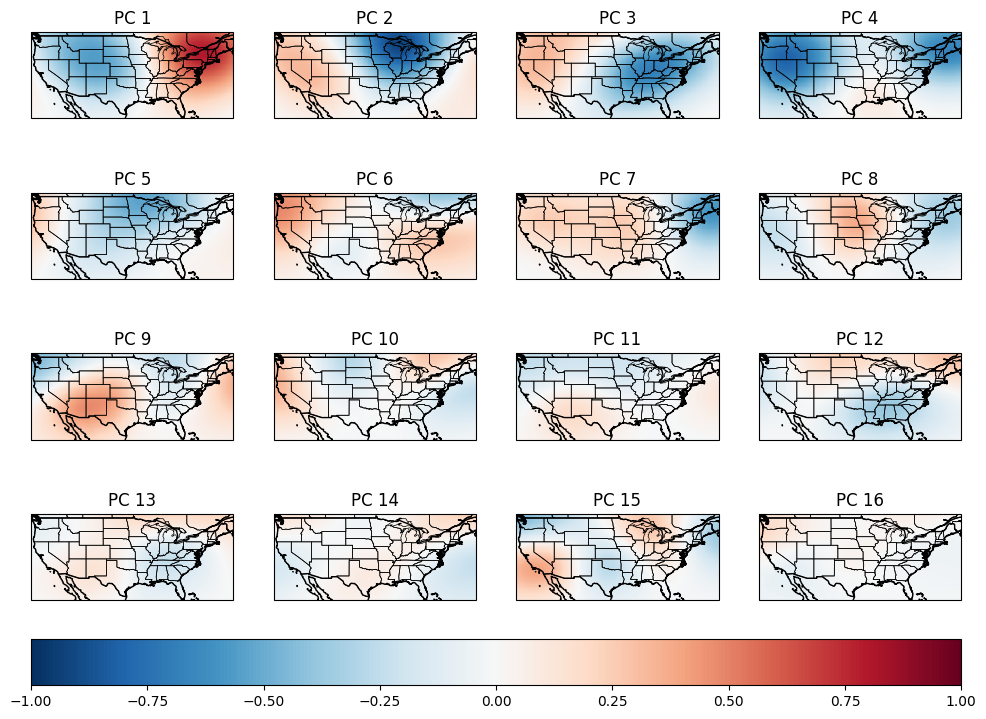

In [16]:
eofs_conus = eof_maps("conus_z500")

lats = anom_w.latitude
lons = anom_w.longitude
fig, axes = plt.subplots(
    4, 4,
    figsize=(12, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for i, ax in enumerate(axes.flat):
    eof = eofs_conus[i]

    im = ax.pcolormesh(
        lons, lats, eof,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin = -1,
        vmax = 1
    )

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, linewidth=0.5)

    ax.set_title(f'PC {i+1}')

# colorbar (shared)
fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', pad=0.05)

plt.show()

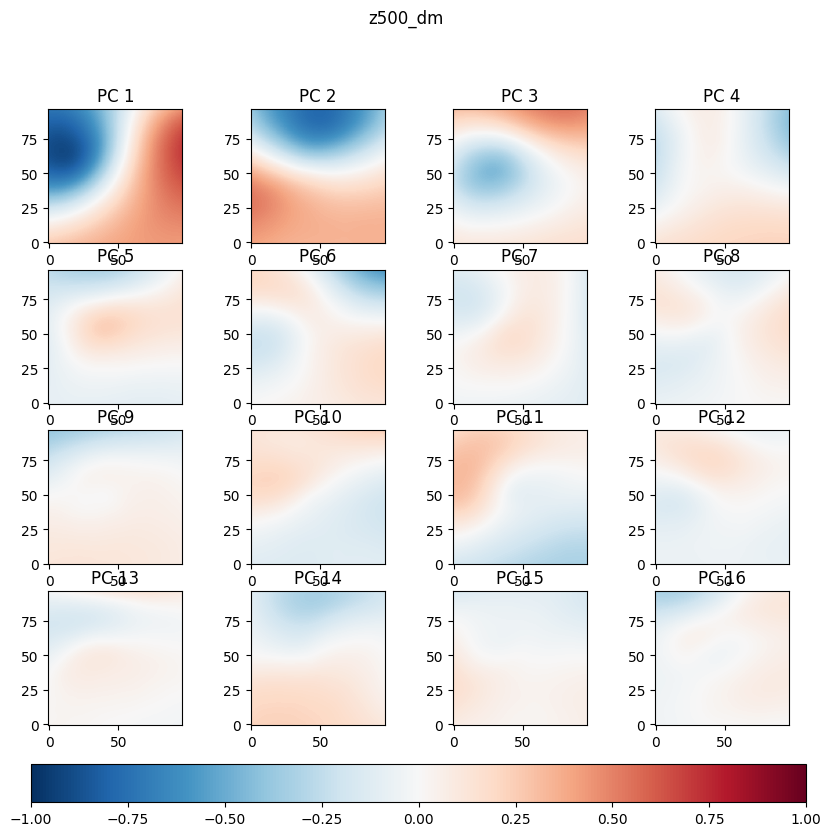

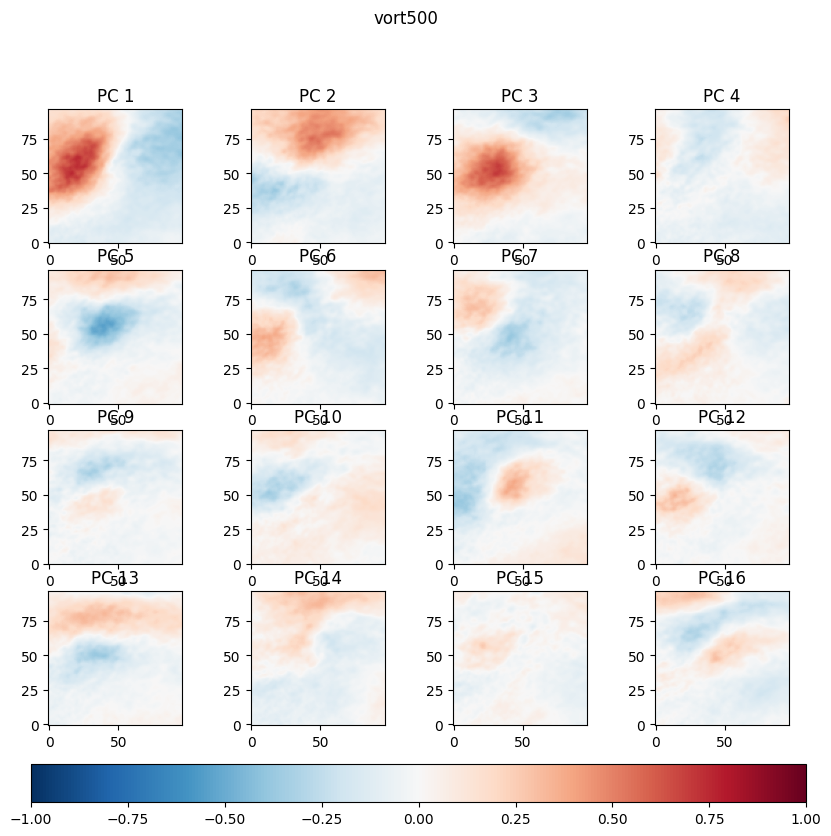

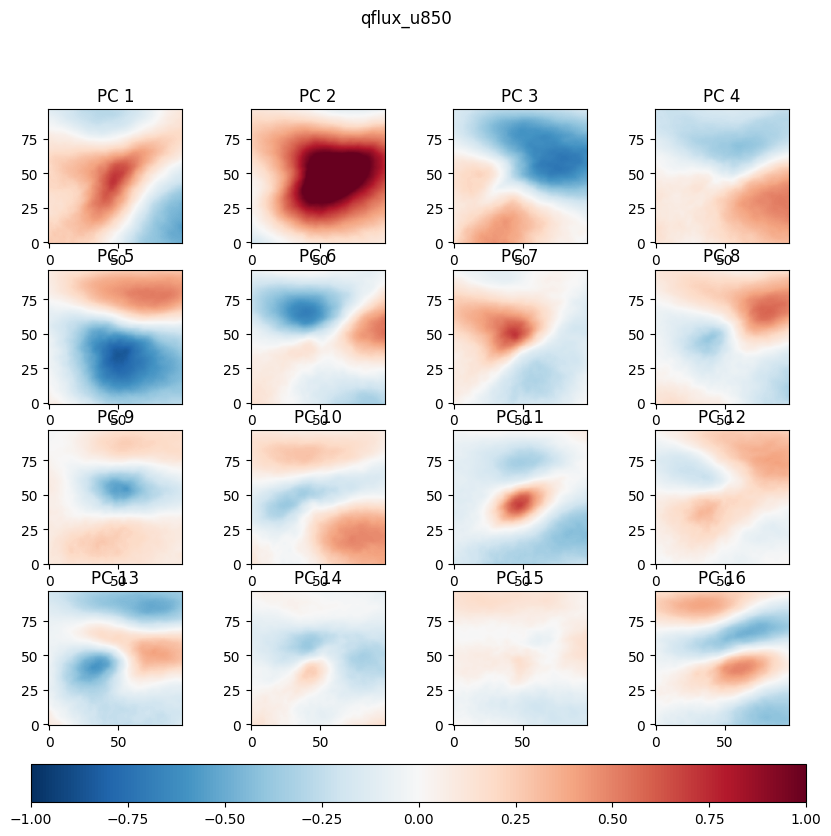

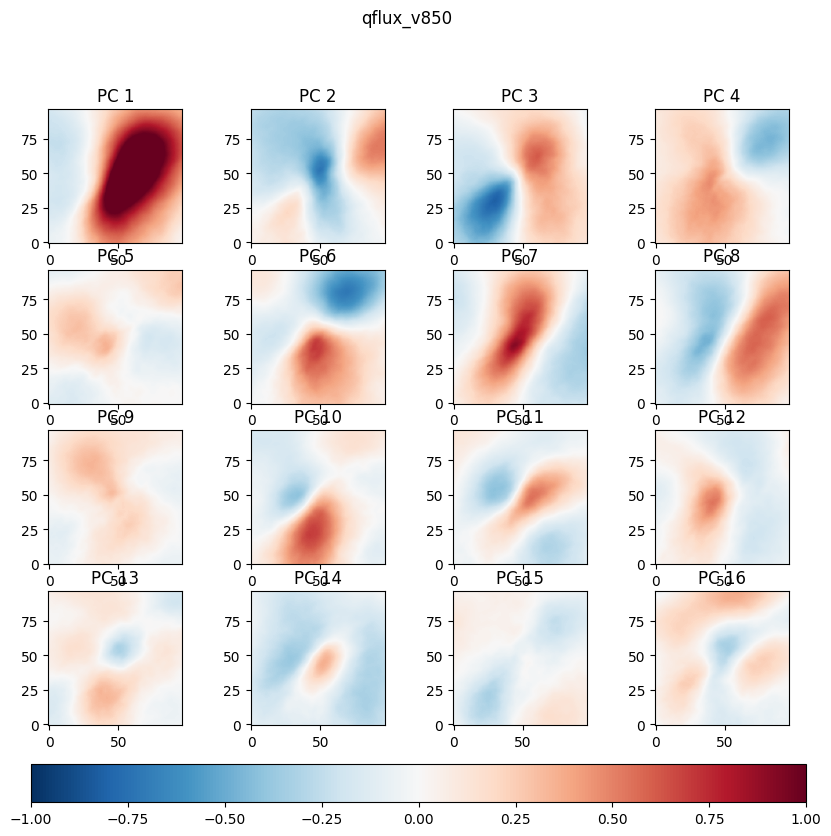

In [17]:
for v in blocks:
    if v != "conus_z500":
        eofs = eof_maps(v)
        # plot
        fig, axes = plt.subplots(4, 4, figsize=(10, 10))

        for i, ax in enumerate(axes.flat):
            im = ax.imshow(
                eofs[i],
                origin="lower",
                cmap="RdBu_r",
                vmin=-1,
                vmax=1,
            )
            ax.set_title(f"PC {i+1}")
        fig.suptitle(v)
        fig.colorbar(im, ax=axes.ravel().tolist(), orientation="horizontal", pad=0.05)
        plt.show()

Doing SOM

In [18]:
size_1 = 3
size_2 = size_1
n_clusters = size_1 * size_2

som = MiniSom(size_1, size_2, PCs.shape[1],
              sigma=.5,
              learning_rate=.1,
              random_seed=42)

som.train(PCs, 200000)
def som_labels(som, X):
    winners = np.array([som.winner(x) for x in X])
    return winners[:,0] * som._weights.shape[1] + winners[:,1]

labels_cluster = som_labels(som, PCs)
score = silhouette_score(PCs, labels_cluster)
counts = np.bincount(labels_cluster)

print(score)
# tuned to highest score.. all vars and 20 pcs:
# for 3x3: sigma .1, learning rate .25, 200000 iterations -> .0677. Sigma .5 -> .0727
# for 4x4: sigma .1, learning rate .1, 200000 iterations -> .0617. Sigma .5 -> .0602

0.058298013791124335


In [19]:
def composite_multivar(labels, feature_ds, heights):
    comps = {}

    for k in np.unique(labels):
        idx = np.where(labels == k)[0]
        days = feature_ds.day.isel(day=idx)

        # storm-centered composites
        storm_comp = (
            feature_ds
            .sel(day=days)
            .mean("day")
        )

        # CONUS height composite
        conus_comp = (
            heights
            .sel(valid_time=days)
            .mean("day")
            .unstack("space")
        )

        comps[k] = dict(
            storm=storm_comp,
            conus=conus_comp
        )

    return comps

In [20]:
outlooks = xr.open_dataset('data/raw_data/grid_outlooks.nc')
reports = xr.open_dataset('data/raw_data/grid_reports.nc')
contingencies = xr.load_dataset('data/raw_data/binary_contingency_regions.nc')
raw_reports = pd.read_csv('data/raw_data/all_reports.csv') 
# subset raw_reports where DATE is in slgt risk days
raw_reports = raw_reports[(raw_reports['DATE'] > '2002-01-01') & (raw_reports['DATE']  < '2020-01-01')]
raw_reports = raw_reports[raw_reports['DATE'].isin(feature_ds.day.values.astype('datetime64[D]').astype(str).tolist())]

C:\Users\miles\AppData\Local\Temp\ipykernel_35540\147489340.py:4: DtypeWarning: Columns (6,15,16,18,22,23,25,27,28,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_reports = pd.read_csv('data/raw_data/all_reports.csv')


In [21]:
outlooks['time'] = pd.to_datetime(outlooks['time'], format='%Y%m%d%H%M')
slgt_outlooks = outlooks.sel(time = pph_time[mask], outlook = 'Day 1 Tornado')
tor_prob_mask = (slgt_outlooks['prob'].max(dim = ['x', 'y']) > 0)
model_spec = 'cnn3d_gelu_0_5/level=slgt_small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL'
results = xr.open_dataset(f'results/predictions_losses/{model_spec}/predictions.nc')
for target_num in range(9):
    print(results.sel(time = tor_prob_mask, target = target_num)['sigma'].mean().values, results.sel(time = ~tor_prob_mask, target = target_num)['sigma'].mean().values)

0.5957981 0.5274173
0.57146376 0.49799493
0.5499232 0.49031317
0.5705262 0.495834
0.44757494 0.4041411
0.42856103 0.38712144
0.43871018 0.22374727
0.26147187 0.042148605
0.29513574 0.026172427


In [22]:
def parse_tor_scale(x):
    """
    Convert F/EF ratings to integer scale.
    Treat:
      F0 == EF0
      F1 == EF1
      ...
      EFU == EF0
    """
    if pd.isna(x):
        return np.nan

    x = str(x).upper().strip()

    if x == 'EFU':
        return 0

    # remove leading EF or F
    if x.startswith('EF'):
        x = x[2:]
    elif x.startswith('F'):
        x = x[1:]

    try:
        return int(x)
    except:
        return np.nan

In [23]:
labels_cluster = som_labels(som, PCs)
all_heights['valid_time'] = feature_ds.day.values

cluster_composites = composite_multivar(
    labels_cluster,
    feature_ds,
    all_heights
)

cluster_data = {}

counts = np.bincount(labels_cluster)

color_dict = {
    'Wind': 'blue',
    'Hail': 'green',
    'Tornado': 'red'
}

for i in range(n_clusters):
    print('Cluster ' + str(i))

    idx = np.where(labels_cluster == i)[0]
    times_cluster = anom.valid_time.isel(valid_time=idx) - np.timedelta64(1, 'D')
    times_str = (times_cluster.dt.strftime('%Y%m%d') + '0000').values

    # --- composites
    storm_fields = cluster_composites[i]["storm"]
    conus_field  = cluster_composites[i]["conus"]

    ol = outlooks.sel(time=times_str)
    rp = reports.sel(time=times_str)

    ol_mean = ol.mean('time')
    rp_mean = rp.mean('time')

    lat = outlooks['lat']
    lon = outlooks['lon']

    def centroid_and_size(weight, power=2):
        w = weight**power
        wsum = w.sum()
        clat = (w * lat).sum() / wsum
        clon = (w * lon).sum() / wsum
        return float(clon), float(clat), float(weight.sum())
    
    def centroid(weight, lat, lon, power=2):
        w = weight**power
        wsum = w.sum()
        clat = (w * lat).sum() / wsum
        clon = (w * lon).sum() / wsum
        return float(clon), float(clat)

    # --- centroid markers
    centroids = []
    for w in [
        ol_mean['prob'].sel(outlook='Day 1 Wind'),
        rp_mean['bool'].sel(hazard='Wind'),
        ol_mean['prob'].sel(outlook='Day 1 Hail'),
        rp_mean['bool'].sel(hazard='Hail'),
        ol_mean['prob'].sel(outlook='Day 1 Tornado'),
        rp_mean['bool'].sel(hazard='Tornado'),
    ]:
        centroids.append(centroid_and_size(w))

    def daily_centroids(da):
        out = []
        for t in da.time:
            clon, clat = centroid(da.sel(time=t), lat, lon)
            out.append((clon, clat))
        return out

    day_centroids = [
        daily_centroids(rp['bool'].sel(hazard='Wind')),
        daily_centroids(rp['bool'].sel(hazard='Hail')),
        daily_centroids(rp['bool'].sel(hazard='Tornado')),
    ]

    # --- seasonal rose
    months = times_cluster.dt.month.values
    month_counts = np.bincount(months-1, minlength=12)

    # --- shift compass means
    compass = {}
    for e_var, n_var in zip(
        ['E_SH_W_NUM','E_SH_H_NUM','E_SH_T_NUM'],
        ['N_SH_W_NUM','N_SH_H_NUM','N_SH_T_NUM']):
        e = pph[e_var].sel(time=times_str).mean().item()
        n = pph[n_var].sel(time=times_str).mean().item()
        compass[(e_var, n_var)] = (e, n)

    # --- skill points
    #skill = {}
    #for far_var, pod_var in zip(
    #    ['FAR_W_NUM','FAR_H_NUM','FAR_T_NUM'],
    #    ['POD_W_NUM','POD_H_NUM','POD_T_NUM']):
    #    x = (1 - pph[far_var].sel(time=times_str).mean()).item()
    #    y = pph[pod_var].sel(time=times_str).mean().item()
    #    skill[(far_var, pod_var)] = (x, y)

    pods = []
    fars = []
    labels_skill = []
    colors = []
    markers = []

    for hazard in ['Wind', 'Hail', 'Tornado']:
        c = contingencies.sel(time = times_str, hazard = hazard)
        pods.append(np.array([c['a'].values.sum()/(c['a'].values.sum() + c['c'].values.sum())]))
        fars.append(np.array([c['b'].values.sum()/(c['a'].values.sum() + c['b'].values.sum())]))
        labels_skill.append(hazard)
        colors.append(color_dict[hazard])
        markers.append('s')

    # --- table quantities
    max_cat_map = {'SLGT':2, 'ENH':3, 'MDT':4, 'HIGH':5}
    vals = np.array([max_cat_map[c] for c in pph.MAX_CAT.sel(time=times_str).values])
    avg_cat = np.nanmean(vals)

    def avg_max_prob(outlook_name):
        probs = ol['prob'].sel(outlook=outlook_name)
        return float(probs.max(('x','y')).mean())

    avg_wind = avg_max_prob('Day 1 Wind')
    avg_hail = avg_max_prob('Day 1 Hail')
    avg_tor  = avg_max_prob('Day 1 Tornado')

    cluster_reports = raw_reports[raw_reports['DATE'].isin(times_cluster.dt.strftime('%Y-%m-%d').values.tolist())]
    cluster_reports = cluster_reports[['EVENT_TYPE', 'MAGNITUDE', 'MAGNITUDE_TYPE', 'TOR_F_SCALE', 'DATE']]
    df = cluster_reports.copy()
    df['TOR_SCALE_NUM'] = df['TOR_F_SCALE'].apply(parse_tor_scale)

    # =========================================================
    # Event subsets
    # =========================================================

    wind = df[df['EVENT_TYPE'] == 'Thunderstorm Wind']
    hail = df[df['EVENT_TYPE'] == 'Hail']
    tor  = df[df['EVENT_TYPE'] == 'Tornado']

    # =========================================================
    # Average number of reports per date
    # =========================================================

    avg_wind_reports_per_date = wind.groupby('DATE').size().mean()
    avg_hail_reports_per_date = hail.groupby('DATE').size().mean()
    avg_tor_reports_per_date  = tor.groupby('DATE').size().mean()

    # =========================================================
    # Average maximum magnitude/rating per date
    # =========================================================

    avg_max_wind_mag_per_date = (
        wind.groupby('DATE')['MAGNITUDE'].max().mean()
    )

    avg_max_hail_mag_per_date = (
        hail.groupby('DATE')['MAGNITUDE'].max().mean()
    )

    avg_max_tor_rating_per_date = (
        tor.groupby('DATE')['TOR_SCALE_NUM'].max().mean()
    )

    # =========================================================
    # Fraction above thresholds
    # =========================================================

    # Wind thresholds
    wind_thresholds = [56, 65, 74, 83]

    wind_fracs = {
        t: (wind['MAGNITUDE'] >= t).mean()
        for t in wind_thresholds
    }

    # Hail thresholds
    hail_thresholds = [1.5, 2, 3.5]

    hail_fracs = {
        t: (hail['MAGNITUDE'] >= t).mean()
        for t in hail_thresholds
    }

    # Tornado thresholds
    tor_thresholds = [1, 2, 3, 4, 5]

    tor_fracs = {
        t: (tor['TOR_SCALE_NUM'] >= t).mean()
        for t in tor_thresholds
    }

    cluster_data[i] = dict(
        storm_fields = storm_fields,
        conus_field  = conus_field,
        count=counts[i],
        centroids=centroids,
        day_centroids=day_centroids,
        rose=month_counts,
        compass=compass,
        pods = pods,
        fars = fars,
        labels_skill = labels_skill,
        colors = colors,
        markers = markers,
        avg_cat=avg_cat,
        avg_wind=avg_wind,
        avg_hail=avg_hail,
        avg_tor=avg_tor,
        avg_wind_reports_per_date = avg_wind_reports_per_date,
        avg_hail_reports_per_date = avg_hail_reports_per_date,
        avg_tor_reports_per_date = avg_tor_reports_per_date,
        avg_max_wind_mag_per_date = avg_max_wind_mag_per_date,
        avg_max_hail_mag_per_date = avg_max_hail_mag_per_date,
        avg_max_tor_mag_per_date = avg_max_tor_rating_per_date,
        wind_fracs = wind_fracs,
        hail_fracs = hail_fracs,
        tor_fracs = tor_fracs
    )

Cluster 0
Cluster 1
Cluster 2
Cluster 3
Cluster 4
Cluster 5
Cluster 6
Cluster 7
Cluster 8


In [24]:
if size_1 == 3:
    save_dir = 'figs/advanced_clustering/'
elif size_1 == 4:
    save_dir = 'figs/advanced_clustering_4/'

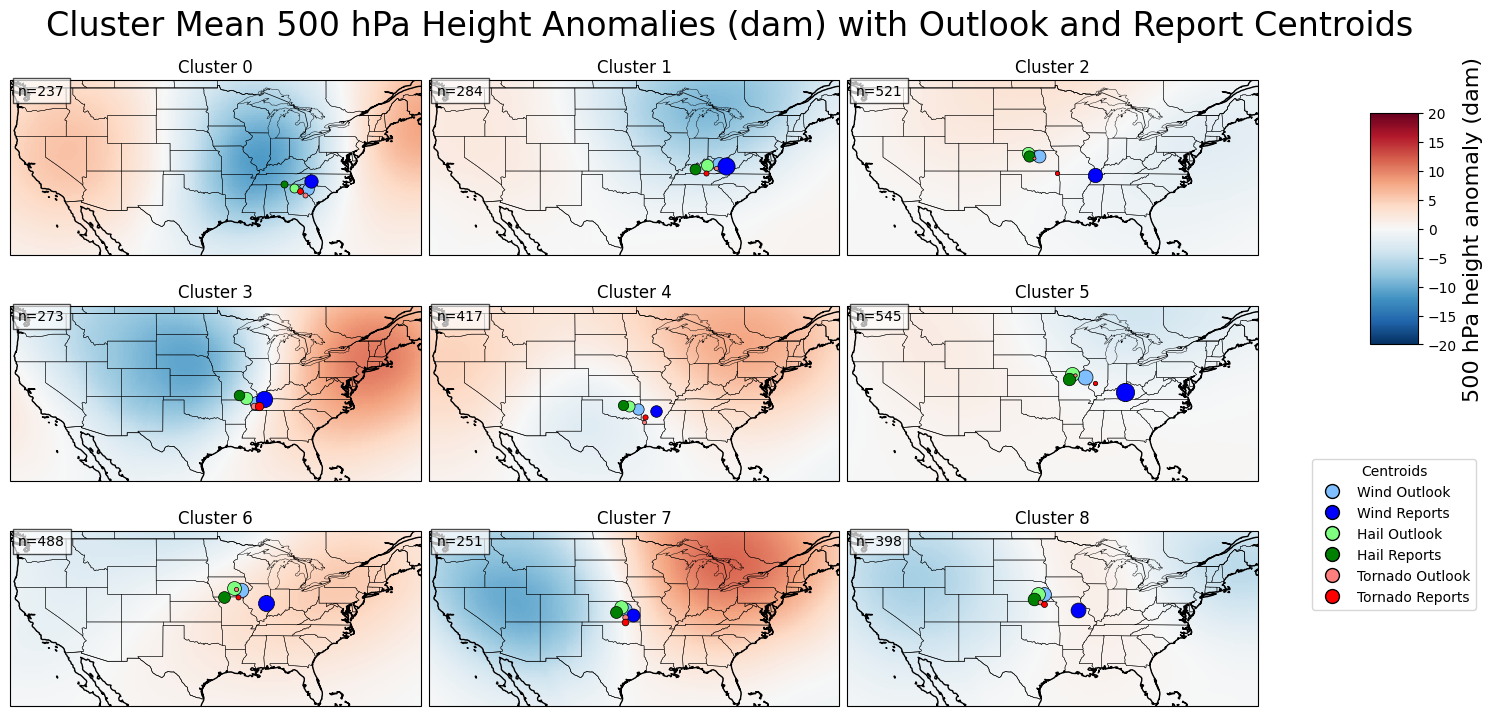

In [25]:
fig = plt.figure(figsize=(16, 8))

# --- main grid for maps (uses constrained layout) ---
gs_maps = fig.add_gridspec(
    nrows=size_1,
    ncols=size_2,
    left=0.05, right=0.83, top=0.92, bottom=0.08,
    wspace=0.02, hspace=0.02
)

axes = []
for r in range(size_1):
    for c in range(size_2):
        ax = fig.add_subplot(gs_maps[r, c], projection=ccrs.PlateCarree())
        axes.append(ax)

# --- side column (independent of map layout) ---
gs_side = fig.add_gridspec(
    nrows=2, ncols=1,
    left=0.90, right=0.93,   # narrower column
    top=0.85, bottom=0.15,
    height_ratios=[1, 1.2]
)

cax = fig.add_subplot(gs_side[0])
lax = fig.add_subplot(gs_side[1])
lax.axis('off')

fig.suptitle(
    'Cluster Mean 500 hPa Height Anomalies (dam) with Outlook and Report Centroids',
    fontsize=24
)


for i, ax in enumerate(axes[:n_clusters]):
    d = cluster_data[i]

    im = ax.pcolormesh(
        d['conus_field']['longitude'],
        d['conus_field']['latitude'],
        d['conus_field'].values,
        cmap='RdBu_r', vmin=-20, vmax=20,
        transform=ccrs.PlateCarree()
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)

    ax.set_title(f'Cluster {i}')
    ax.text(
        0.02, 0.98, f'n={d["count"]}',
        transform=ax.transAxes, ha='left', va='top',
        bbox=dict(facecolor='white', alpha=0.7)
    )

    for (clon, clat, size), color in zip(
        d['centroids'],
        ['#7fbfff','blue','#7fff7f','green','#ff7f7f','red']
    ):
        ax.scatter(
            clon, clat, s=size*5, color=color,
            edgecolor='k', linewidth=0.5,
            transform=ccrs.PlateCarree(), zorder=10
        )

# colorbar lives in its own gridspec column
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('500 hPa height anomaly (dam)', fontsize=16)


# --- legend proxies ---
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#7fbfff', markeredgecolor='k', markersize=10,
           label='Wind Outlook'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='blue', markeredgecolor='k', markersize=10,
           label='Wind Reports'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#7fff7f', markeredgecolor='k', markersize=10,
           label='Hail Outlook'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='green', markeredgecolor='k', markersize=10,
           label='Hail Reports'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#ff7f7f', markeredgecolor='k', markersize=10,
           label='Tornado Outlook'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='red', markeredgecolor='k', markersize=10,
           label='Tornado Reports'),
]
# legend
lax.legend(
    handles=legend_elements,
    loc='center',
    frameon=True,
    title='Centroids'
)

plt.savefig(save_dir + 'composites.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig(save_dir + 'composites.png', dpi = 1000, bbox_inches='tight')
plt.show()

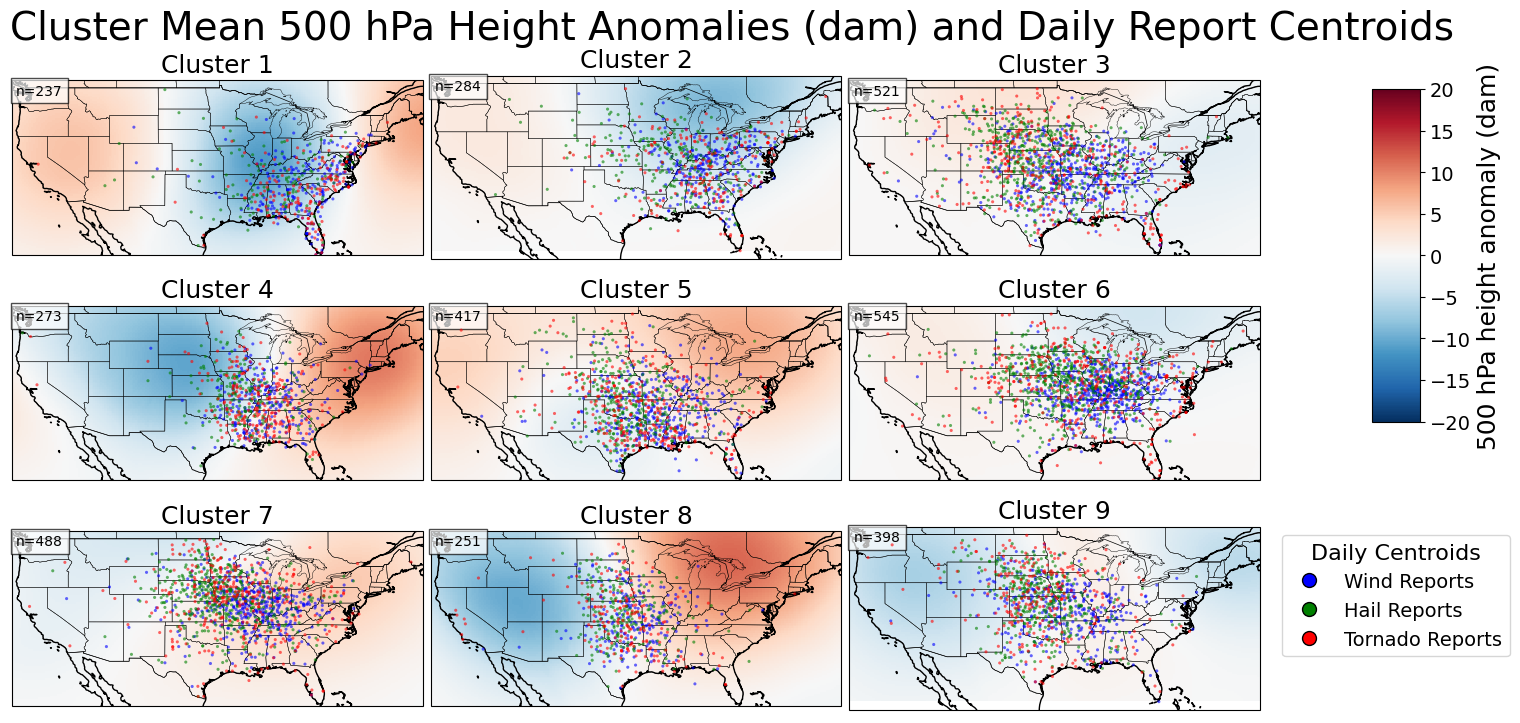

In [28]:
fig = plt.figure(figsize=(16, 8))

# --- main grid for maps (uses constrained layout) ---
gs_maps = fig.add_gridspec(
    nrows=size_1,
    ncols=size_2,
    left=0.05, right=0.83, top=0.92, bottom=0.08,
    wspace=0.02, hspace=0.02
)

axes = []
for r in range(size_1):
    for c in range(size_2):
        ax = fig.add_subplot(gs_maps[r, c], projection=ccrs.PlateCarree())
        axes.append(ax)

# --- side column (independent of map layout) ---
gs_side = fig.add_gridspec(
    nrows=2, ncols=1,
    left=0.90, right=0.93,   # narrower column
    top=0.88, bottom=0.10,
    height_ratios=[1.7, 1.2]
)

cax = fig.add_subplot(gs_side[0])
lax = fig.add_subplot(gs_side[1])
lax.axis('off')

fig.suptitle(
    'Cluster Mean 500 hPa Height Anomalies (dam) and Daily Report Centroids',
    fontsize=28
)


for i, ax in enumerate(axes[:n_clusters]):
    d = cluster_data[i]

    im = ax.pcolormesh(
        d['conus_field']['longitude'],
        d['conus_field']['latitude'],
        d['conus_field'].values,
        cmap='RdBu_r', vmin=-20, vmax=20,
        transform=ccrs.PlateCarree()
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)

    ax.set_title(f'Cluster {i+1}', fontsize=18)
    ax.text(
        0.01, 0.98, f'n={d["count"]}',
        transform=ax.transAxes, ha='left', va='top',
        bbox=dict(facecolor='white', alpha=0.7)
    )

    for pts, color in zip(
    d['day_centroids'],
        ['blue', 'green', 'red']
    ):
        lons, lats = zip(*pts)
        # remove all non-conus points (lat outside 24-50, lon outside -125 to -66)
        lons1 = [lon for lon, lat in zip(lons, lats) if 24 <= lat <= 50 and -125 <= lon <= -66]
        lats1 = [lat for lon, lat in zip(lons, lats) if 24 <= lat <= 50 and -125 <= lon <= -66]
        
        ax.scatter(
            lons1, lats1,
            s=5, alpha=0.6,
            color=color,
            edgecolor='none',
            transform=ccrs.PlateCarree(),
            zorder=10
        )

# colorbar lives in its own gridspec column
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('500 hPa height anomaly (dam)', fontsize=18)
cbar.ax.tick_params(labelsize=14)


# --- legend proxies ---
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='blue', markeredgecolor='k', markersize=10,
           label='Wind Reports'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='green', markeredgecolor='k', markersize=10,
           label='Hail Reports'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='red', markeredgecolor='k', markersize=10,
           label='Tornado Reports'),
]
# legend
lax.legend(
    handles=legend_elements,
    loc='center',
    frameon=True,
    title='Daily Centroids',
    fontsize=14,
    title_fontsize=16
)

plt.savefig(save_dir + 'composites_v2.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig(save_dir + 'composites_v2.png', dpi = 1000, bbox_inches='tight')
plt.show()

In [34]:
Ny = 97
Nx = 97
center = 48  # index of center point

deg = (np.arange(Nx) - center) / 4.0

def plot_storm_field(varname, vmin, vmax, cmap, title, savepath):
    fig = plt.figure(figsize=(9, 8))

    gs_maps = fig.add_gridspec(
        nrows=size_1,
        ncols=size_2,
        left=0.08, right=0.83, top=0.90, bottom=0.08,
        wspace=0, hspace=0.25
    )

    axes = []
    for r in range(size_1):
        for c in range(size_2):
            ax = fig.add_subplot(gs_maps[r, c])
            axes.append(ax)

    gs_side = fig.add_gridspec(
        nrows=1, ncols=1,
        left=0.88, right=0.91,
        top=0.85, bottom=0.15,
    )
    cax = fig.add_subplot(gs_side[0])

    fig.suptitle(title, fontsize=28)

    for i, ax in enumerate(axes[:n_clusters]):
        d = cluster_data[i]
        field = d["storm_fields"][varname]

        field_values = field.values
        if varname == 'z500_dm':
            field_values = field_values / 98.1  # convert to dam

        im = ax.imshow(
            field_values,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            extent=[deg[0], deg[-1], deg[0], deg[-1]],
            aspect="equal",
        )

        ax.set_xticks([-10, -5, 0, 5, 10])
        ax.set_yticks([-10, -5, 0, 5, 10])

        ax.set_title(f'Cluster {i+1}', pad=6, fontsize=16)
        ax.text(
            0.03, 0.98, f'n={d["count"]}',
            transform=ax.transAxes, ha='left', va='top',
            bbox=dict(facecolor='white', alpha=0.7)
        )

        if i % size_2 == 0:
            ax.set_ylabel("Degrees from center", fontsize=14)
        else:
            ax.tick_params(labelleft=False)
        if i // size_2 == size_1 - 1:
            ax.set_xlabel("Degrees from center", fontsize=14)
        else:
            ax.tick_params(labelbottom=False)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('500 hPa eddy height (dam)', fontsize=18)

    plt.savefig(savepath + ".pdf", dpi=1000, bbox_inches='tight')
    plt.savefig(savepath + ".png", dpi=1000, bbox_inches='tight')
    plt.show()

def plot_storm_vector_field(
    u_var, v_var,
    vmin, vmax,
    cmap,
    title,
    savepath,
    stride=5,
    scale=2
):
    fig = plt.figure(figsize=(9, 8))

    gs_maps = fig.add_gridspec(
        nrows=size_1,
        ncols=size_2,
        left=0.08, right=0.83, top=0.90, bottom=0.08,
        wspace=0, hspace=0.25
    )

    axes = []
    for r in range(size_1):
        for c in range(size_2):
            ax = fig.add_subplot(gs_maps[r, c])
            axes.append(ax)

    gs_side = fig.add_gridspec(
        nrows=1, ncols=1,
        left=0.88, right=0.91,
        top=0.85, bottom=0.15,
    )
    cax = fig.add_subplot(gs_side[0])

    fig.suptitle(title, fontsize=24)

    # grid for quiver
    X, Y = np.meshgrid(deg, deg)

    for i, ax in enumerate(axes[:n_clusters]):
        d = cluster_data[i]

        u = d["storm_fields"][u_var].values
        v = d["storm_fields"][v_var].values

        mag = np.sqrt(u**2 + v**2)

        im = ax.imshow(
            mag,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            extent=[deg[0], deg[-1], deg[0], deg[-1]],
            aspect="equal",
        )

        ax.set_xticks([-10, -5, 0, 5, 10])
        ax.set_yticks([-10, -5, 0, 5, 10])

        ax.quiver(
            X[::stride, ::stride],
            Y[::stride, ::stride],
            u[::stride, ::stride],
            v[::stride, ::stride],
            color="black",
            scale=scale,
            width=0.003
        )

        ax.set_title(f'Cluster {i+1}', pad=6, fontsize=16)
        ax.text(
            0.03, 0.98, f'n={d["count"]}',
            transform=ax.transAxes, ha='left', va='top',
            bbox=dict(facecolor='white', alpha=0.7)
        )
        
        if i % size_2 == 0:
            ax.set_ylabel("Degrees from center", fontsize=14)
        else:
            ax.tick_params(labelleft=False)
        if i // size_2 == size_1 - 1:
            ax.set_xlabel("Degrees from center", fontsize=14)
        else:
            ax.tick_params(labelbottom=False)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Specific humidity flux (m/s)", fontsize=18)

    plt.savefig(savepath + ".pdf", dpi=1000, bbox_inches='tight')
    plt.savefig(savepath + ".png", dpi=1000, bbox_inches='tight')
    plt.show()

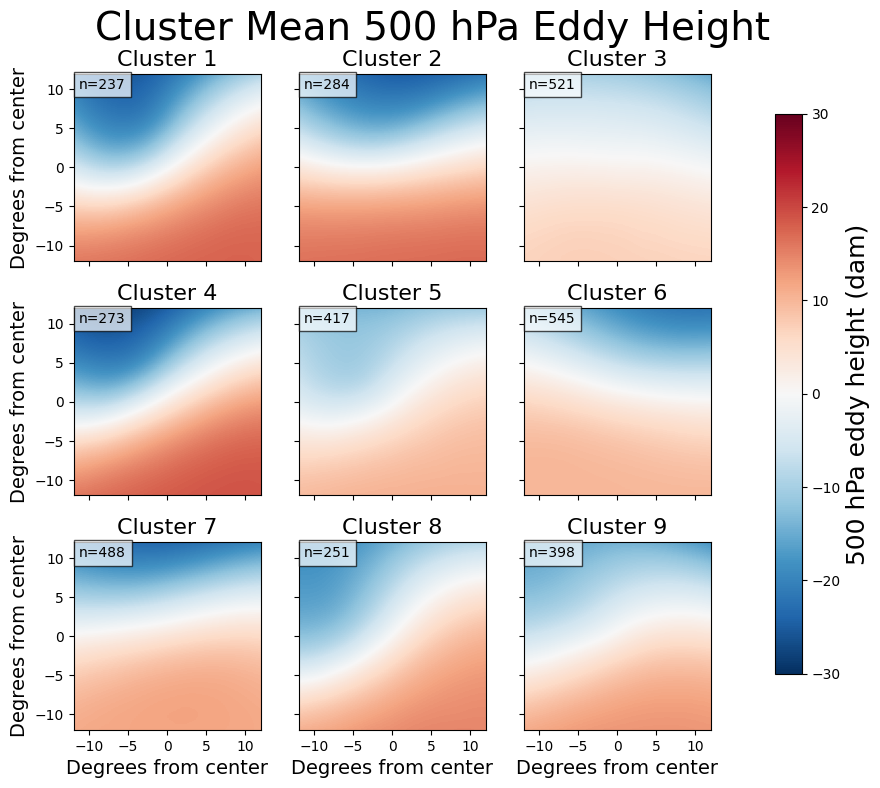

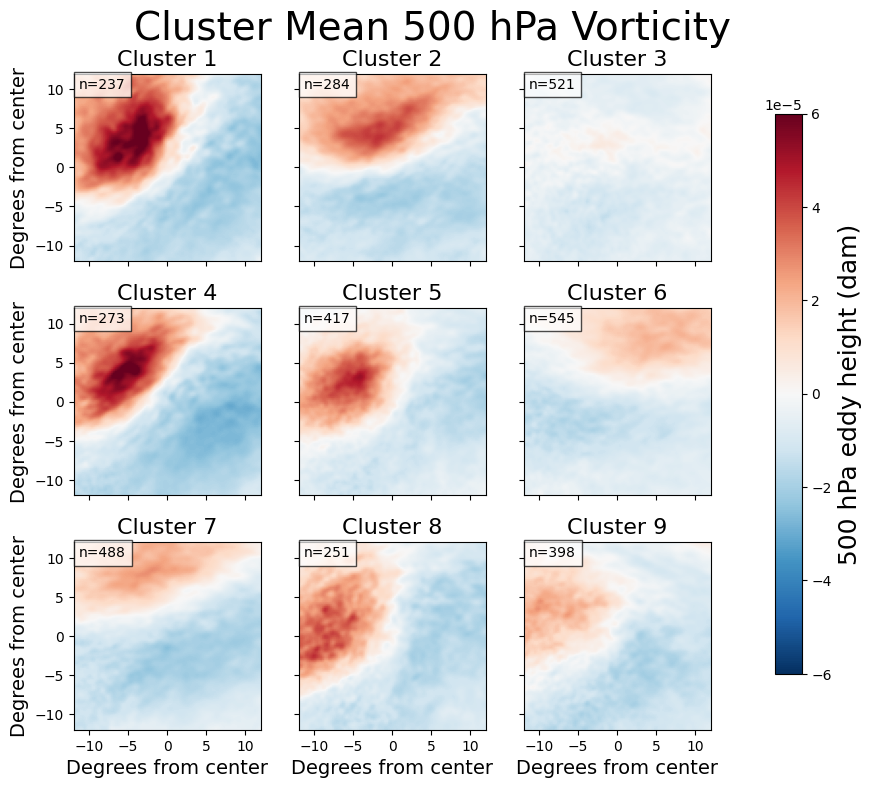

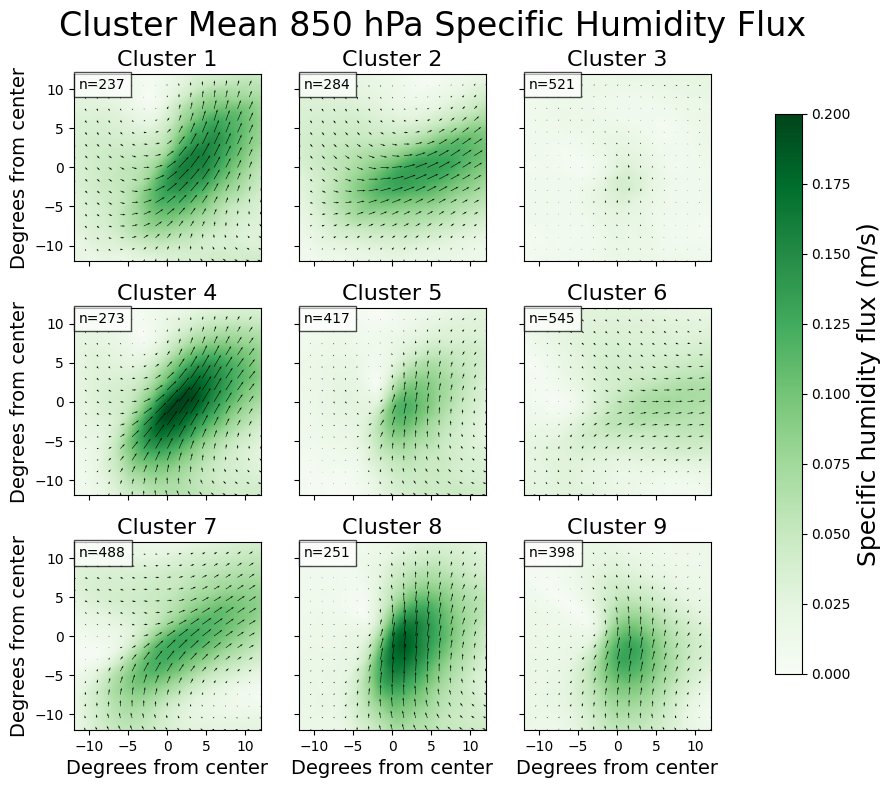

In [35]:
plot_storm_field(
    "z500_dm",
    vmin=-30, vmax=30,
    cmap="RdBu_r",
    title="Cluster Mean 500 hPa Eddy Height",
    savepath=save_dir + "z500_dm_composites"
)

plot_storm_field(
    "vort500",
    vmin=-6e-5, vmax=6e-5,
    cmap="RdBu_r",
    title="Cluster Mean 500 hPa Vorticity",
    savepath=save_dir + "vort500_composites"
)

#plot_storm_field(
#    "lap_z500",
#    vmin=-1e-8, vmax=1e-8,
#    cmap="RdBu_r",
#    title="Cluster Mean Laplacian of z500",
#    savepath=save_dir + "lap_z500_composites"
#)

plot_storm_vector_field(
    "qflux_u850",
    "qflux_v850",
    vmin=0,
    vmax=0.20,
    cmap="Greens",
    title="Cluster Mean 850 hPa Specific Humidity Flux",
    savepath=save_dir + "qflux_vectors_850",
    stride=6
)

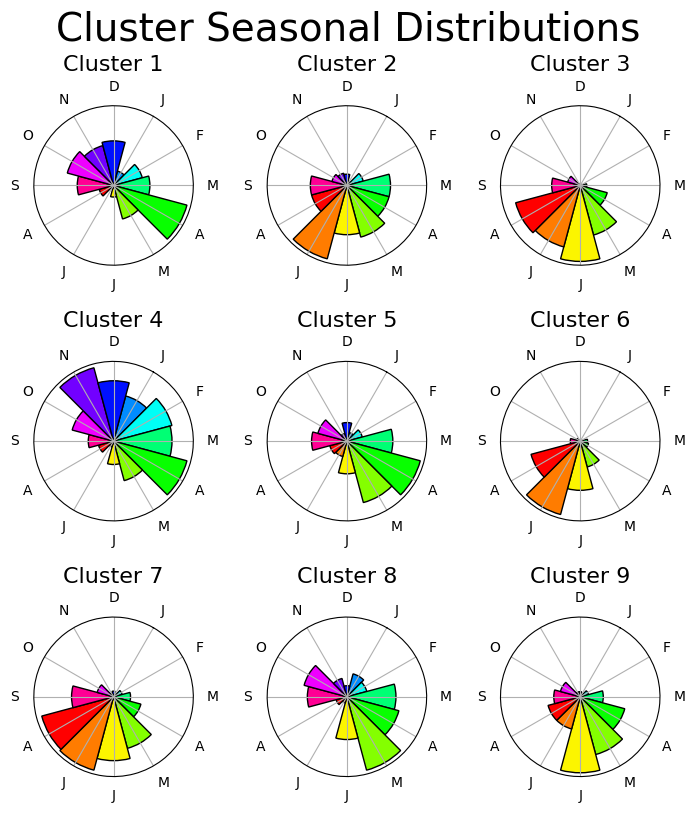

In [44]:
import matplotlib.cm as cm
fig, axes = plt.subplots(
    size_1, size_2,
    subplot_kw={'polar': True},
    figsize=(7, 8),
    constrained_layout=True
)

fig.get_layout_engine().set(hspace=0.08)
fig.suptitle('Cluster Seasonal Distributions', fontsize=28)

axes = axes.ravel()
angles = np.linspace(0, 2*np.pi, 12, endpoint=False)
labels = np.array(['J','F','M','A','M','J','J','A','S','O','N','D'])

# Color mapping:
# start hue at September, then proceed backward through the year
start = 7  # September
month_order = (start - np.arange(12)) % 12
colors_by_month = cm.hsv(month_order / 12.0)

for i, ax in enumerate(axes[:n_clusters]):
    counts = cluster_data[i]['rose']

    # Polar orientation: December at top, CCW months
    ax.set_theta_zero_location('N')   # top
    ax.set_theta_offset(ax.get_theta_offset() - np.pi/6)  # shift one month so Dec is at top
    ax.set_theta_direction(-1)         # clockwise

    ax.bar(
        angles,
        counts,
        width=2*np.pi/12,
        color=colors_by_month,
        edgecolor='k'
    )

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticks([])
    ax.set_title(f'Cluster {i+1}', fontsize=16)

plt.savefig(save_dir + 'seasonal.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig(save_dir + 'seasonal.png', dpi = 1000, bbox_inches='tight')

In [45]:
import fitz  # PyMuPDF
import string

save_dir = "figs/advanced_clustering/"

# row layout: composites_v2 alone on top, the other three across the bottom
top_row = [save_dir + "composites_v2.pdf"]
bottom_row = [save_dir + "seasonal.pdf", save_dir + "z500_dm_composites.pdf", save_dir + "qflux_vectors_850.pdf"]
rows = [top_row, bottom_row]
labels = string.ascii_lowercase  # a, b, c, d, ...

docs = {path: fitz.open(path) for row in rows for path in row}
sizes = {path: doc[0].rect for path, doc in docs.items()}

# normalize each row to a common height (its own images' max native height),
# then lay images out edge-to-edge (no gap) at that height, preserving each
# image's own aspect ratio -- avoids the empty side-padding you get from
# forcing every image into a shared, globally-sized cell.
row_scale = [1.1, 1.0]  # blow up the top row (composites_v2) 10%; it's narrower than the bottom row
row_heights = [max(sizes[path].height for path in row) * scale for row, scale in zip(rows, row_scale)]
row_widths = []
row_layouts = []  # list of (path, width, height) per row, at row height
for row, row_h in zip(rows, row_heights):
    layout = []
    for path in row:
        r = sizes[path]
        w = r.width * (row_h / r.height)
        layout.append((path, w, row_h))
    row_layouts.append(layout)
    row_widths.append(sum(w for _, w, _ in layout))

page_w = max(row_widths)
page_h = sum(row_heights)

out = fitz.open()
page = out.new_page(width=page_w, height=page_h)

label_idx = 0
y_cursor = 0
for row, layout, row_w, row_h in zip(rows, row_layouts, row_widths, row_heights):
    x_cursor = (page_w - row_w) / 2  # center rows narrower than the page
    for path, w, h in layout:
        rect = fitz.Rect(x_cursor, y_cursor, x_cursor + w, y_cursor + h)
        page.show_pdf_page(rect, docs[path], 0)

        # nudge the first label left of its image (into the surrounding
        # whitespace) since composites_v2 has its own text up to the corner
        x_nudge = -30 if label_idx == 0 else 4
        label_point = fitz.Point(rect.x0 + x_nudge, rect.y0 + 16)
        page.insert_text(label_point, f"({labels[label_idx]})", fontsize=20, fontname="helv", color=(0, 0, 0))
        label_idx += 1
        x_cursor += w
    y_cursor += row_h

out_path_pdf = save_dir + "combined_cluster_fig.pdf"
out.save(out_path_pdf)

pix = out[0].get_pixmap(dpi=300)
pix.save(save_dir + "combined_cluster_fig.png")


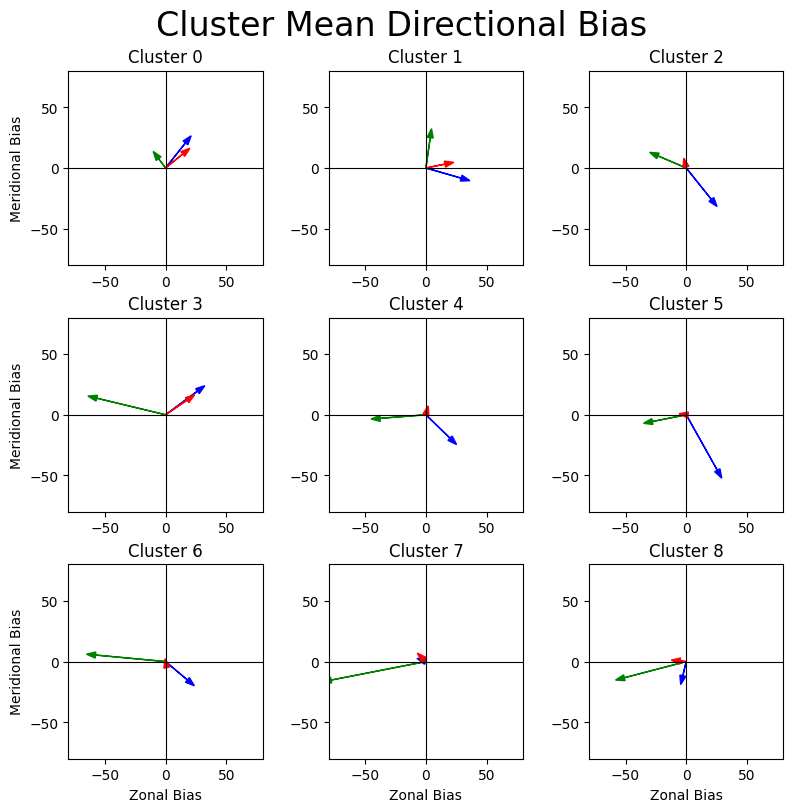

In [30]:
fig, axes = plt.subplots(
    size_1, size_2,
    figsize=(8, 8),
    constrained_layout=True
)
axes = axes.ravel()

fig.suptitle('Cluster Mean Directional Bias', fontsize=24)

scale = 1000

plot_width = 80

for i, ax in enumerate(axes[:n_clusters]):
    ax.set_aspect('equal')
    ax.set_xlim(-plot_width, plot_width)
    ax.set_ylim(-plot_width, plot_width)

    # Centered axes
    ax.axhline(0, color='k', linewidth=0.8)
    ax.axvline(0, color='k', linewidth=0.8)

    for (e_var, n_var), color in zip(
        cluster_data[i]['compass'],
        ['blue', 'green', 'red']
    ):
        e, n = cluster_data[i]['compass'][(e_var, n_var)]
        ax.arrow(
            0, 0,
            e/scale, n/scale,
            color=color,
            width=0.03,
            length_includes_head=True,
            head_width=5
        )
    if i in [0, 3, 6]:
        ax.set_ylabel('Meridional Bias')
    if i in [6, 7, 8]:
        ax.set_xlabel('Zonal Bias')
    
    ax.set_title(f'Cluster {i}')

plt.savefig(save_dir + 'directional.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig(save_dir + 'directional.png', dpi = 1000, bbox_inches='tight')

In [31]:
# Adapted from https://gist.github.com/djgagne/64516e3ea268ec31fb34

def performance_diagram(pods, fars, obj_labels, colors, markers, filename = '', save = False, show = True, figsize=(9, 8), points = True, xlabel="Success Ratio (1-FAR)",
                        ylabel="Probability of Detection", ticks=np.arange(0, .6, 0.1), dpi=300, csi_cmap="Blues",
                        csi_label="Critical Success Index", title="Performance Diagram",
                        legend_params=dict(loc=4, fontsize=12, framealpha=1, frameon=True),
                        ax = None, show_cbar=False, show_legend=False, show_xlabel = False, show_ylabel = False):
    """
    Draws a performance diagram from a set of POD lists and FAR lists.
    :param pods: list or array of POD arrays.
    :param fars: list or array of FAR arrays.
    :param obj_labels: list or array of labels describing each DistributedROC object.
    :param colors: list of color strings
    :param markers: list of markers.
    :param filename: output filename.
    :param save: whether the figure will be saved
    :param show: whether the figure will be shown in the console
    :param figsize: tuple with size of the figure in inches.
    :param points: True if the plotted points should be separate, otherwise connected
    :param xlabel: Label for the x-axis
    :param ylabel: Label for the y-axis
    :param ticks: Array of ticks used for x and y axes
    :param dpi: DPI of the output image
    :param csi_cmap: Colormap used for the CSI contours
    :param csi_label: Label for the CSI colorbar
    :param ax: Axis object to plot the diagram
    :return:
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        own_fig = True
    else:
        fig = ax.figure  # Get figure from existing axis
        own_fig = False

    grid_ticks = np.arange(0, .51, 0.01)
    sr_g, pod_g = np.meshgrid(grid_ticks, grid_ticks)
    bias = pod_g / sr_g
    csi = 1.0 / (1.0 / sr_g + 1.0 / pod_g - 1.0)

    csi_contour = ax.contourf(sr_g, pod_g, csi, np.arange(.025, .325, 0.025), extend="max", cmap=csi_cmap)
    b_contour = ax.contour(sr_g, pod_g, bias, [.25, 0.5, 1, 2, 4], colors="k", linestyles="dashed")
    ax.clabel(b_contour, fmt="%1.2f", manual=[(0.1, 0.45), (0.2, 0.45), (0.35, 0.35), (.45, .2), (.45, .1)])
    for r, (pod, far) in enumerate(zip(pods, fars)):
        if points:
            ax.scatter(1 - far, pod, color=colors[r], label=obj_labels[r], s = 50)
        else:
            ax.plot(1 - far, pod, marker=markers[r], color=colors[r], label=obj_labels[r], markersize = 5, linewidth = 1)
            shift0 = .03
            shift1 = .03
            if r == 3:
                shift1 = 0
            ax.annotate('2002', xy = (1-far[1], pod[1]), xytext=(1-far[1]-shift1, pod[1]+shift0), arrowprops=dict(arrowstyle="->"))
            ax.annotate('2023', xy = (1-far[-1], pod[-1]), xytext=(1-far[-1]+shift0, pod[-1]-shift1), arrowprops=dict(arrowstyle="->"))
    if show_xlabel:
        ax.set_xlabel(xlabel, fontsize=14)
    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_title(title, fontsize=14)
    ax.text(0.24,0.28,"Frequency Bias",fontdict=dict(fontsize=8, rotation=45))

    if len(obj_labels) > 8:
        legend_params=dict(loc='center left', bbox_to_anchor=(1.3, 0.5), fontsize=12, framealpha=1, frameon=True)
    
    cbar = None
    if show_cbar:
        cbar = fig.colorbar(csi_contour)
        cbar.set_label(csi_label, fontsize=14)

    if show_legend:
        ax.legend(**legend_params)

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    if show and own_fig:
        plt.show()
    return csi_contour

C:\Users\miles\AppData\Local\Temp\ipykernel_29064\2464297428.py:38: RuntimeWarning: divide by zero encountered in divide
  bias = pod_g / sr_g
C:\Users\miles\AppData\Local\Temp\ipykernel_29064\2464297428.py:38: RuntimeWarning: invalid value encountered in divide
  bias = pod_g / sr_g
C:\Users\miles\AppData\Local\Temp\ipykernel_29064\2464297428.py:39: RuntimeWarning: divide by zero encountered in divide
  csi = 1.0 / (1.0 / sr_g + 1.0 / pod_g - 1.0)


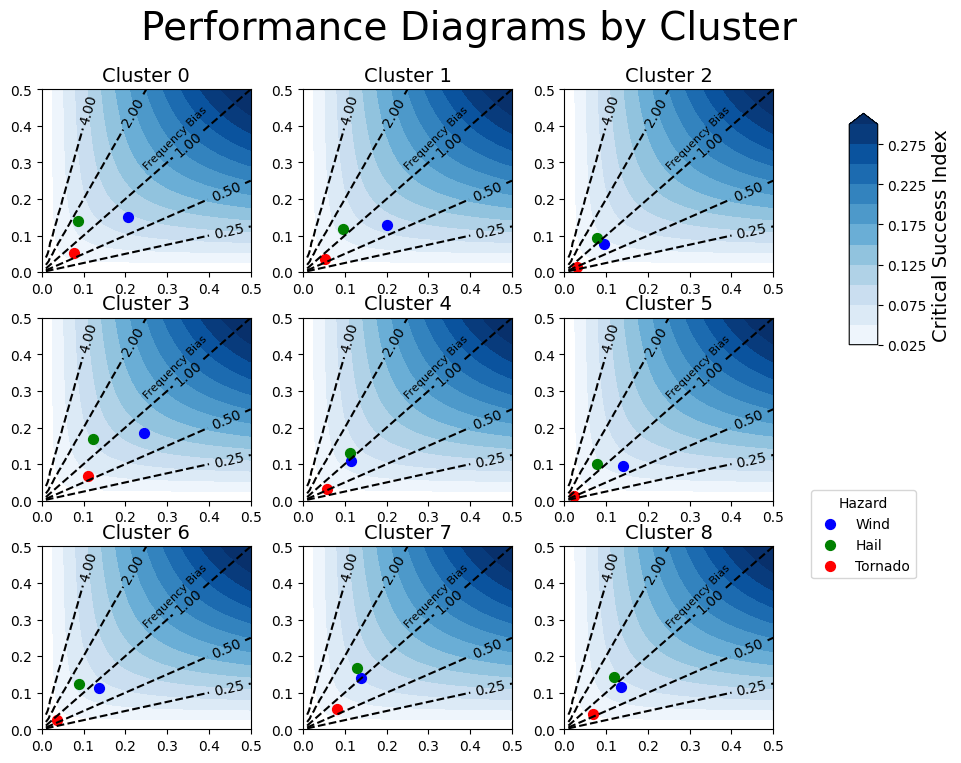

In [32]:
fig = plt.figure(figsize=(9.5, 8))

gs_maps = fig.add_gridspec(
    nrows=size_1,
    ncols=size_2,
    left=0.05, right=0.82,
    top=0.88, bottom=0.08,
    wspace=0.25, hspace=0.25
)

gs_side = fig.add_gridspec(
    nrows=2, ncols=1,
    left=0.90, right=0.93,   # narrower column
    top=0.85, bottom=0.15,
    height_ratios=[1, 1.2]
)

cax = fig.add_subplot(gs_side[0])
lax = fig.add_subplot(gs_side[1])
lax.axis('off')

fig.suptitle('Performance Diagrams by Cluster', fontsize=28)

axes = []
for i in range(size_1 * size_2):
    ax = fig.add_subplot(gs_maps[i // size_2, i % size_2])
    axes.append(ax)

# --- plotting ---
for i in range(n_clusters):
    d = cluster_data[i]

    csi_contour = performance_diagram(
        d['pods'],
        d['fars'],
        d['labels_skill'],
        d['colors'],
        d['markers'],
        ax=axes[i],
        title=f'Cluster {i}',
        show_cbar=False,
        show_legend=False
    )

cbar = fig.colorbar(csi_contour, cax=cax)
cbar.set_label("Critical Success Index", fontsize=14)

handles, labels = axes[0].get_legend_handles_labels()

lax.legend(
    handles,
    labels,
    loc='center',
    frameon=True,
    title='Hazard'
)

plt.savefig(save_dir + 'performance_diagram.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig(save_dir + 'performance_diagram.png', dpi = 1000, bbox_inches='tight')

In [33]:
rows = []
for i in range(n_clusters):
    d = cluster_data[i]
    rows.append([
        i,
        d['avg_cat'],
        d['avg_wind'],
        d['avg_hail'],
        d['avg_tor'],
        d['avg_wind_reports_per_date'],
        d['avg_hail_reports_per_date'],
        d['avg_tor_reports_per_date'],
        d['avg_max_wind_mag_per_date'],
        d['avg_max_hail_mag_per_date'],
        d['avg_max_tor_mag_per_date'],
        d['wind_fracs'][56],
        d['wind_fracs'][65],
        d['wind_fracs'][74],
        d['wind_fracs'][83],
        d['hail_fracs'][1.5],
        d['hail_fracs'][2],
        d['hail_fracs'][3.5],
        d['tor_fracs'][1],
        d['tor_fracs'][2],
        d['tor_fracs'][3],
        d['tor_fracs'][4],
        d['tor_fracs'][5]
    ])

table = pd.DataFrame(rows, columns=[
    'Cluster',
    'Avg Category',
    'Avg Max Wind Prob',
    'Avg Max Hail Prob',
    'Avg Max Tornado Prob',
    'Avg Wind Reports',
    'Avg Hail Reports',
    'Avg Tor Reports',
    'Avg Max Wind Speed',
    'Avg Max Hail Size',
    'Avg Max Tor Rating',
    'Frac Wind 56',
    'Frac Wind 65',
    'Frac Wind 74',
    'Frac Wind 83',
    'Frac Hail 1.5',
    'Frac Hail 2',
    'Frac Hail 3.5',
    'Frac Tor 1',
    'Frac Tor 2',
    'Frac Tor 3',
    'Frac Tor 4',
    'Frac Tor 5'

])

table#.to_csv(save_dir + 'cluster_summary.csv', index = False)

,Cluster,Avg Category,Avg Max Wind Prob,Avg Max Hail Prob,Avg Max Tornado Prob,Avg Wind Reports,Avg Hail Reports,Avg Tor Reports,Avg Max Wind Speed,Avg Max Hail Size,...,Frac Wind 74,Frac Wind 83,Frac Hail 1.5,Frac Hail 2,Frac Hail 3.5,Frac Tor 1,Frac Tor 2,Frac Tor 3,Frac Tor 4,Frac Tor 5
0,0,2.286920,0.198734,0.105485,0.053882,73.321101,35.746988,12.223529,68.353211,1.778916,...,0.011762,0.003253,0.198349,0.036569,0.002528,0.589028,0.150626,0.031280,0.001444,0.000000
1,1,2.302817,0.213028,0.149824,0.039859,116.298182,67.892308,8.311005,73.211679,2.231269,...,0.012851,0.004565,0.227623,0.048550,0.003682,0.528497,0.142199,0.029937,0.004030,0.000000
2,2,2.067179,0.161708,0.166795,0.027582,58.330693,56.058708,4.919689,71.161845,2.435245,...,0.013783,0.003768,0.235391,0.057530,0.004887,0.222222,0.040021,0.008425,0.001053,0.000000
3,3,2.619048,0.238462,0.176557,0.077692,85.571970,70.741379,21.585903,71.431818,2.217241,...,0.017706,0.005223,0.220205,0.050024,0.003961,0.604490,0.212653,0.067959,0.015918,0.002245
4,4,2.266187,0.172302,0.179496,0.043477,38.356771,55.494624,8.218069,68.735602,2.343925,...,0.018467,0.006110,0.229122,0.056530,0.003197,0.365428,0.078848,0.013268,0.001895,0.000000
5,5,2.093578,0.183578,0.176972,0.026752,107.503731,72.683333,5.000000,73.308411,2.484370,...,0.012322,0.003176,0.215725,0.052384,0.003440,0.339303,0.061194,0.007463,0.001990,0.000000
6,6,2.237705,0.203586,0.194877,0.037643,85.120430,71.106157,7.038674,72.886810,2.423397,...,0.016043,0.004876,0.213251,0.050461,0.003702,0.425432,0.104788,0.026295,0.004710,0.000392
7,7,2.494024,0.199203,0.229084,0.062550,47.352423,72.210300,14.826316,71.351858,2.488112,...,0.027351,0.006977,0.241426,0.061694,0.004636,0.432020,0.126376,0.033724,0.004970,0.000355
8,8,2.361809,0.195477,0.224623,0.051156,68.602778,77.085106,11.236486,72.641667,2.710027,...,0.019314,0.006114,0.266181,0.069832,0.006555,0.373422,0.116957,0.037883,0.007517,0.000301


In [34]:
# look at model perfromance for each cluster2

model_spec = 'cnn3d_gelu_0_5/level=slgt_small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL'
results = xr.open_dataset(f'results/predictions_losses/{model_spec}/predictions.nc')
results['cluster'] = (('time'), labels_cluster)

In [35]:
# for each cluster, calculate NLL, baseline NLL, llr, KL(?). Good product could be 9x9 heatmap for each of these

from scipy.stats import chi2

# variables to aggregate
base = results[['nll_pred', 'nll_baseline', 'llr_vals', 'kl_vals', 'mu', 'sigma', 'gamma', 'tau']]

# mean metrics per cluster/target
cluster_means = (
    base
    .groupby(results.cluster)
    .mean(dim='time')
    .rename({'cluster': 'cluster_id'})
)

# number of days in each cluster
Nc = results['cluster'].groupby(results.cluster).count()
Nc = Nc.rename({'cluster': 'cluster_id'})  # (cluster_id,)

# broadcast Nc to (cluster_id, target)
Nc2d = Nc.expand_dims(target=cluster_means.target)

# Λ = 2 * N_c * LLR
Lambda = 2.0 * Nc2d * cluster_means['llr_vals']
Lambda.name = 'lambda_stat'

# optional: chi-square p-value (using k=4 as discussed)
k = 4
pval = xr.apply_ufunc(lambda x: chi2.sf(x, k), Lambda)
pval.name = 'p_value'

# add to dataset
cluster_means = xr.merge([cluster_means, Lambda, pval])

lr_values = (np.exp(cluster_means['llr_vals']) - 1)
lr_values.name = 'likelihood_improvement'

cluster_means = xr.merge([cluster_means, lr_values])

C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


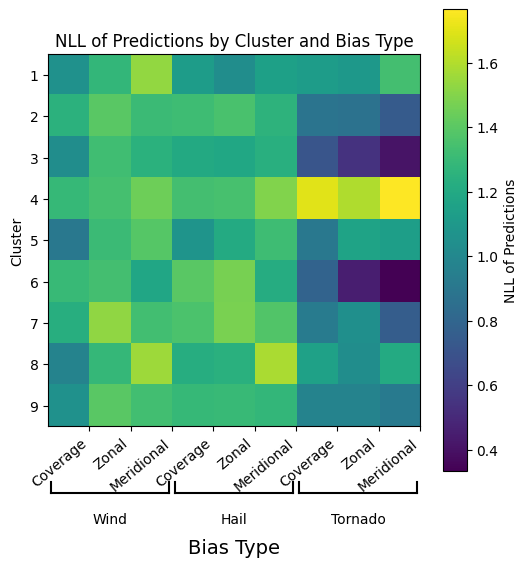

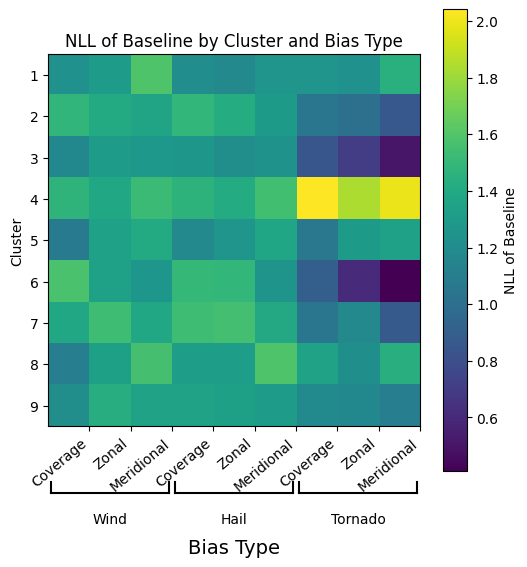

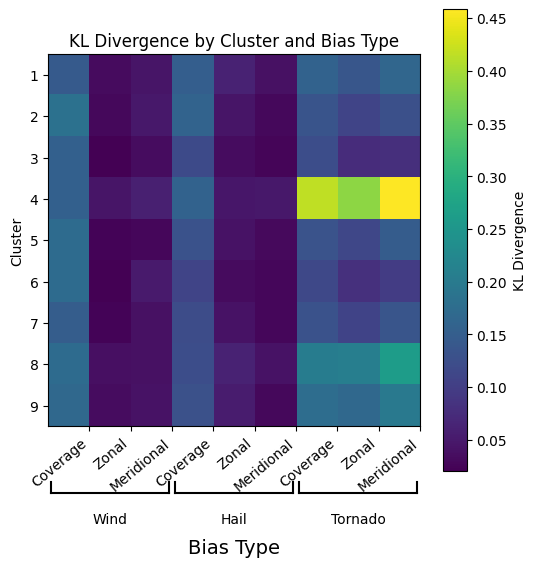

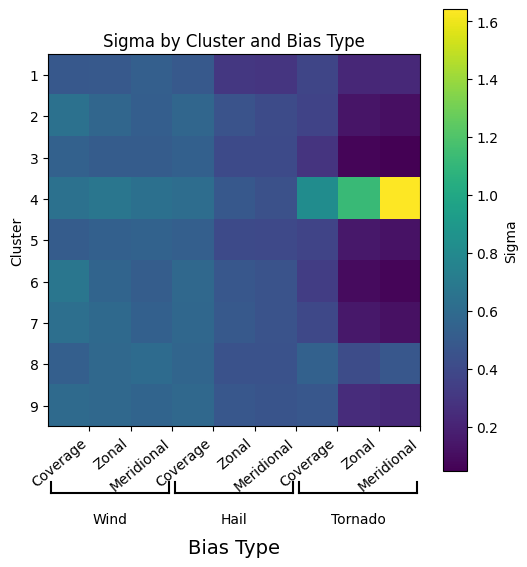

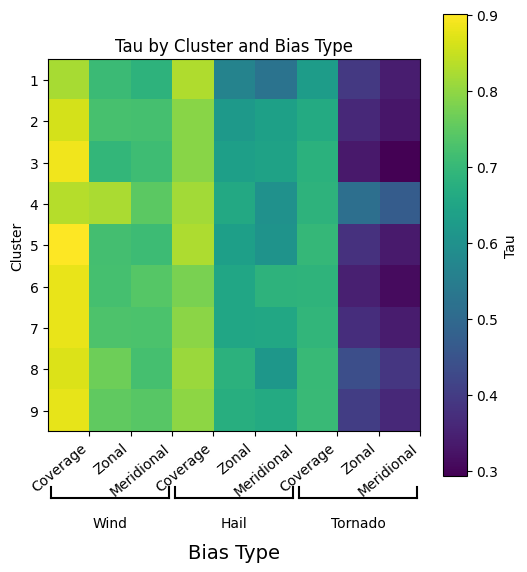

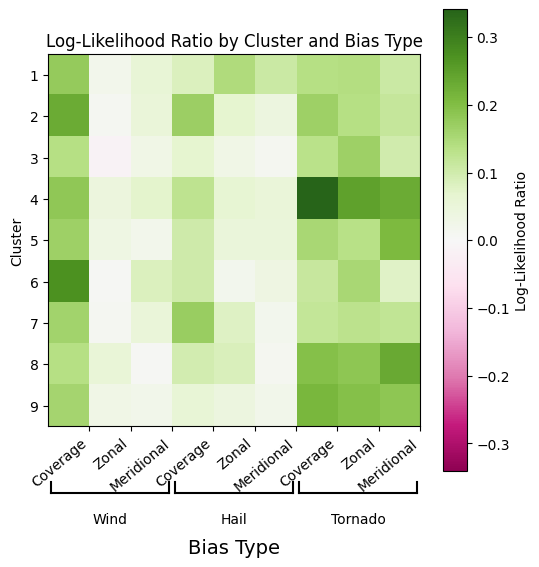

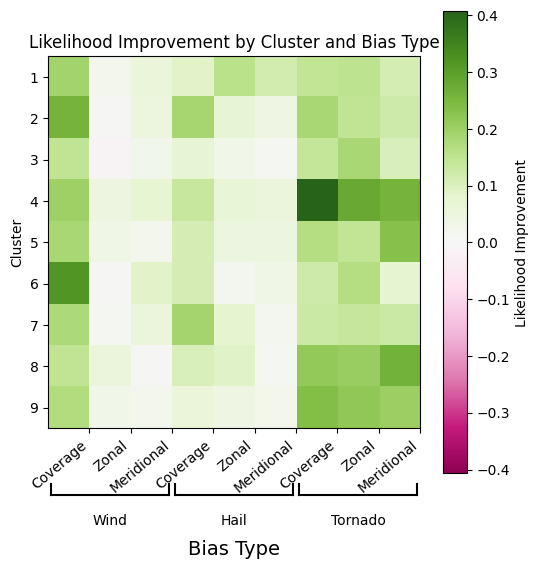

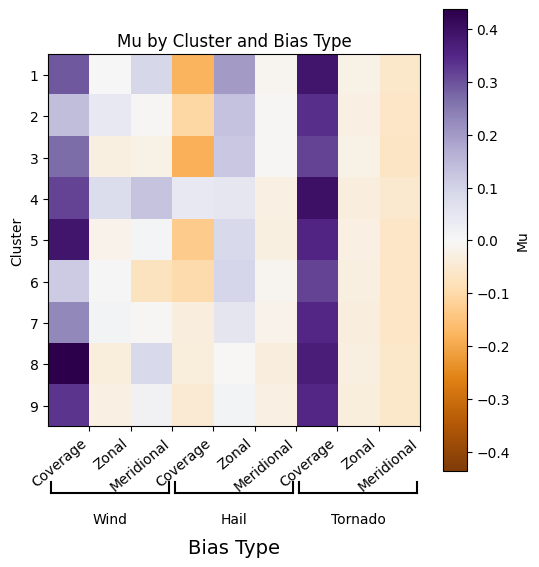

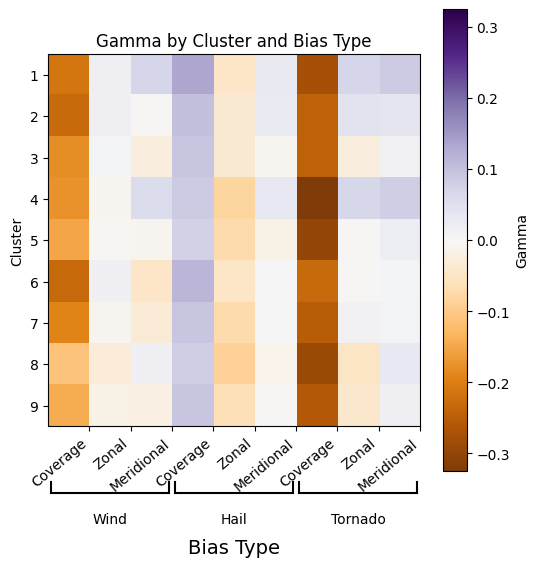

In [36]:
vars_seq = ['nll_pred', 'nll_baseline', 'kl_vals', 'sigma', 'tau']  # sequential
var_div = ['llr_vals', 'likelihood_improvement', 'mu', 'gamma']                       # diverging

name_dict = {
     'nll_pred': 'NLL of Predictions',
     'nll_baseline': 'NLL of Baseline',
     'kl_vals': 'KL Divergence',
     'sigma': 'Sigma',
     'tau': 'Tau',
     'llr_vals': 'Log-Likelihood Ratio',
     'likelihood_improvement': 'Likelihood Improvement',
     'mu': 'Mu',
     'gamma': 'Gamma',
}


def format_target_axis(ax):
    # --- inner labels ---
    inner = ['Coverage', 'Zonal', 'Meridional'] * 3
    ax.set_xticks(np.arange(0.5, 9.5, 1))
    ax.set_xticklabels(['Coverage', 'Zonal', 'Meridional'] * 3, rotation=40, ha='right')

    # --- remove any secondary axis artifacts ---
    # (important: avoids duplicate hazard labels)
    for child in ax.get_children():
        if isinstance(child, plt.SecondaryAxis if hasattr(plt, "SecondaryAxis") else type(None)):
            pass

    ax.text(0.5, -0.30, 'Bias Type', transform=ax.transAxes,
        ha='center', va='top', fontsize=14)

    # --- bracket groups (manual, black only) ---
    y = -0.18
    groups = [(0, 2), (3, 5), (6, 8)]
    labels = ['Wind', 'Hail', 'Tornado']

    gap = 0.015  # tweak to taste

    for (x0, x1), lab in zip(groups, labels):
        x0f, x1f = x0 / 9 + gap / 2, (x1 + 1) / 9 - gap / 2


        ax.plot([x0f, x1f], [y, y],
                transform=ax.transAxes, clip_on=False,
                color='black')

        ax.plot([x0f, x0f], [y, y + 0.03],
                transform=ax.transAxes, clip_on=False,
                color='black')

        ax.plot([x1f, x1f], [y, y + 0.03],
                transform=ax.transAxes, clip_on=False,
                color='black')

        ax.text((x0f + x1f) / 2, y - 0.05, lab,
                transform=ax.transAxes,
                ha='center', va='top', color='black')
        

# --- sequential colormap plots ---
for v in vars_seq:
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cluster_means[v], aspect='equal')
    fig.colorbar(im, ax=ax, label=name_dict[v])

    # ax.set_xlabel('Target')
    ax.set_ylabel('Cluster')
    ax.set_yticks(range(size_1 * size_2))
    ax.set_yticklabels(range(1, size_1 * size_2 + 1))
    ax.set_title(name_dict[v] + ' by Cluster and Bias Type')

    format_target_axis(ax)
    plt.savefig(f'{save_dir}heatmaps/{v}.pdf', dpi = 1000, bbox_inches='tight')
    plt.savefig(f'{save_dir}heatmaps/{v}.png', dpi = 1000, bbox_inches='tight')
    plt.show()

for v in var_div:
        # --- diverging for llr ---
        llr = cluster_means[v]
        vmax = abs(llr).max().item()

        fig, ax = plt.subplots(figsize=(6, 6))
        if v in ['llr_vals', 'likelihood_improvement']:
             cmap = 'PiYG'
        else:
             cmap = 'PuOr'
        im = ax.imshow(llr, aspect='equal', vmin=-vmax, vmax=vmax, cmap=cmap)
        fig.colorbar(im, ax=ax, label=name_dict[v])

        # ax.set_xlabel('Target')
        ax.set_ylabel('Cluster')
        ax.set_yticks(range(size_1 * size_2))
        ax.set_yticklabels(range(1, size_1 * size_2 + 1))
        ax.set_title(name_dict[v] + ' by Cluster and Bias Type')

        format_target_axis(ax)
        plt.savefig(f'{save_dir}heatmaps/{v}.pdf', dpi = 1000, bbox_inches='tight')
        plt.savefig(f'{save_dir}heatmaps/{v}.png', dpi = 1000, bbox_inches='tight')
        plt.show()